In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
import scipy.stats as st
from scipy.stats import randint,uniform
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.tree import export_text
import graphviz
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor
import optuna.visualization as vis

In [4]:
df = pd.read_csv("../data/clean/airbnbnyc_final.csv")
df.head()

,host_is_superhost,neighbourhood_group_cleansed,latitude,longitude,room_type,accommodates,bedrooms,price,maximum_nights,availability_365,number_of_reviews,calculated_host_listings_count,total_amenities
0,False,Brooklyn,40.64529,-73.97238,Private room,1.098612,1.0,285.0,730,347,2.302585,1.945910,761
1,False,Manhattan,40.75356,-73.98559,Entire home/apt,0.693147,0.0,240.0,1125,312,3.912023,1.386294,553
2,False,Brooklyn,40.66265,-73.99454,Entire home/apt,1.609438,2.0,215.0,730,80,1.609438,0.693147,816
3,True,Brooklyn,40.70935,-73.95342,Entire home/apt,1.386294,2.0,97.0,120,219,5.283204,0.693147,384
4,False,Manhattan,40.78778,-73.94759,Private room,0.693147,2.0,63.0,120,254,5.537334,0.693147,364


# Train test Split

In [5]:

features = df.drop(columns = ["price"])
target = df["price"]
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=0)

# Encoding Categorical Column

In [6]:
ohe = OneHotEncoder(drop="first",sparse_output=False) 
ohe.fit(X_train[['host_is_superhost','neighbourhood_group_cleansed','room_type']]) # The .fit() method determines the unique values of each column
X_train_trans_np = ohe.transform(X_train[['host_is_superhost','neighbourhood_group_cleansed','room_type']])
X_train_trans_df = pd.DataFrame(X_train_trans_np, columns=ohe.get_feature_names_out(), index=X_train.index)
X_test_trans_np = ohe.transform(X_test[['host_is_superhost','neighbourhood_group_cleansed','room_type']])
X_test_trans_df = pd.DataFrame(X_test_trans_np, columns=ohe.get_feature_names_out(), index=X_test.index)

# Saving Encoder

In [7]:
with open("../encoders/one_hot_encoder.pkl", "wb") as file:
    pickle.dump(ohe, file)

# Combining data after encoding

In [8]:
X_train_num=X_train.select_dtypes('number')

X_test_num=X_test.select_dtypes('number')

X_train_full=pd.concat([X_train_trans_df,X_train_num],axis=1)
X_test_full=pd.concat([X_test_trans_df,X_test_num],axis=1)

# Scaling

In [9]:
std_scaler = StandardScaler()
std_scaler.fit(X_train_full)


,copy,True
,with_mean,True
,with_std,True


# Saving scaler

In [10]:
with open("../scalers/standard_scaler.pkl", "wb") as file:
    pickle.dump(std_scaler, file)

In [11]:
X_train_full_np = std_scaler.transform(X_train_full)
X_test_full_np  = std_scaler.transform(X_test_full)

X_train_full_np_df = pd.DataFrame(X_train_full_np, columns=X_train_full.columns, index=X_train_full.index)
X_test_full_np_df  = pd.DataFrame(X_test_full_np, columns=X_test_full.columns, index=X_test_full.index)

# KNN Regressor Before Tuning

The R² of the model on the TEST set is:  0.66
Mean Absolute Error (MAE):  54.28
Mean Squared Error (MSE):  6961.70
Root Mean Squared Error (RMSE):  83.44


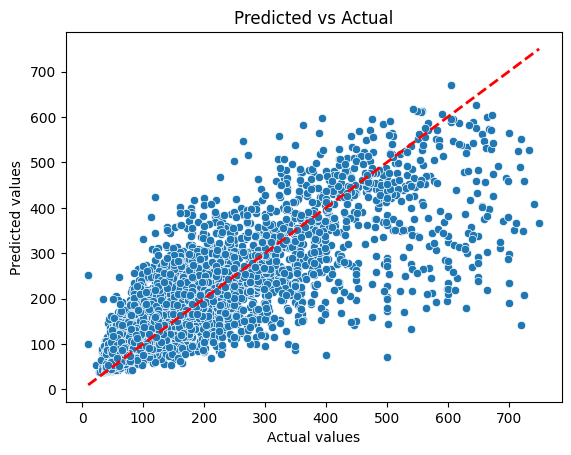

In [10]:
#KNN Regressor - modeling
knn = KNeighborsRegressor(n_neighbors=9)
#Training KNN to our normalized data
knn.fit(X_train_full_np_df, y_train)

# Predict on test set
y_pred = knn.predict(X_test_full_np_df)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print metrics
print(f"The R² of the model on the TEST set is: {r2: .2f}")
print(f"Mean Absolute Error (MAE): {mae: .2f}")
print(f"Mean Squared Error (MSE): {mse: .2f}")
print(f"Root Mean Squared Error (RMSE): {rmse: .2f}")

#scatter plot
sns.scatterplot(x=y_test, y=y_pred)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred)),
    max(max(y_test), max(y_pred))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual")
plt.show()

# Hyperparameter Tuning for KNN Regressor

# Grid Search

In [ ]:


# Hyperparameter grid
parameter_grid = {
    "n_neighbors": [3,5,10,20],
    "weights": ['uniform', 'distance'],
    "leaf_size": [20,30,40],
    "p":[1,2],
    "metric":['minkowski','manhattan','euclidean']
}

# Model
kr = KNeighborsRegressor()

# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(kr, param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits


# Random Search

In [10]:
# Define parameters
parameter_distributions = {
    "n_neighbors":randint(1,50),
    "weights": ['uniform', 'distance'],
    "p":[1,2],
    "leaf_size":randint(10,100),
    "algorithm":['auto','ball_tree','kd_tree','brute']
    
}

# Model instance
kr1 =  KNeighborsRegressor()

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 30

rs = RandomizedSearchCV(
    kr,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 3/5; 1/30] START algorithm=kd_tree, leaf_size=61, n_neighbors=29, p=1, weights=uniform
[CV 2/5; 1/30] START algorithm=kd_tree, leaf_size=61, n_neighbors=29, p=1, weights=uniform
[CV 1/5; 1/30] START algorithm=kd_tree, leaf_size=61, n_neighbors=29, p=1, weights=uniform
[CV 4/5; 1/30] START algorithm=kd_tree, leaf_size=61, n_neighbors=29, p=1, weights=uniform
[CV 5/5; 1/30] START algorithm=kd_tree, leaf_size=61, n_neighbors=29, p=1, weights=uniform
[CV 1/5; 2/30] START algorithm=brute, leaf_size=70, n_neighbors=21, p=1, weights=distance
[CV 2/5; 2/30] START algorithm=brute, leaf_size=70, n_neighbors=21, p=1, weights=distance
[CV 3/5; 2/30] START algorithm=brute, leaf_size=70, n_neighbors=21, p=1, weights=distance
[CV 4/5; 2/30] START algorithm=brute, leaf_size=70, n_neighbors=21, p=1, weights=distance
[CV 5/5; 2/30] START algorithm=brute, leaf_size=70, n_neighbors=21, p=1, weights=distance
[CV 1/5; 2/30] END algorithm=brut

# Bayesian Search

In [11]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights",['uniform','distance'])
    p = trial.suggest_int("p", 1, 2)
    leaf_size = trial.suggest_int("leaf_size", 10, 100)
    algorithm = trial.suggest_categorical("agorithm", ['auto','ball_tree','kd_tree','brute'])

    # Initialize model
    kr2 = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        leaf_size=leaf_size,
        algorithm=algorithm
    )

    # Cross-validation
    scores = cross_val_score(kr2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-12 16:47:13,069] A new study created in memory with name: no-name-6ac4edd9-3032-473f-afed-f9f1ac5b173c
[I 2025-08-12 16:47:15,908] Trial 0 finished with value: 0.6453527239205401 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'p': 2, 'leaf_size': 20, 'agorithm': 'kd_tree'}. Best is trial 0 with value: 0.6453527239205401.
[I 2025-08-12 16:47:16,288] Trial 1 finished with value: 0.6845584641067445 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 1, 'leaf_size': 58, 'agorithm': 'brute'}. Best is trial 1 with value: 0.6845584641067445.
[I 2025-08-12 16:47:16,717] Trial 2 finished with value: 0.670163986153917 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 1, 'leaf_size': 79, 'agorithm': 'brute'}. Best is trial 1 with value: 0.6845584641067445.
[I 2025-08-12 16:47:18,951] Trial 3 finished with value: 0.6432423723784926 and parameters: {'n_neighbors': 20, 'weights': 'uniform', 'p': 2, 'leaf_size': 68, 'agorithm': 'kd_tree'}. Best is trial 1



Time taken:  56.6411 seconds

Best hyperparameters found: {'n_neighbors': 11, 'weights': 'distance', 'p': 1, 'leaf_size': 48, 'agorithm': 'ball_tree'}
 Best R² found:  0.6868
 R² confidence interval of best trial: (np.float64(0.6762), np.float64(0.6868), np.float64(0.6975))


# KNN Regressor After Tuning

In [11]:
knn_tuned = KNeighborsRegressor(n_neighbors=11,algorithm='kd_tree',leaf_size=96,p=1,weights='distance',metric='minkowski')
knn_tuned.fit(X_train_full_np_df, y_train)


,n_neighbors,11
,weights,'distance'
,algorithm,'kd_tree'
,leaf_size,96
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Saving model

In [12]:
with open("../models/knn_tuned.pkl", "wb") as file:
    pickle.dump(knn_tuned, file)

The R² of the model on the TEST set is:  0.71
Mean Absolute Error (MAE):  49.57
Mean Squared Error (MSE):  5976.53
Root Mean Squared Error (RMSE):  77.31
Mean Absolute Percentage Error (MAPE):  30.86


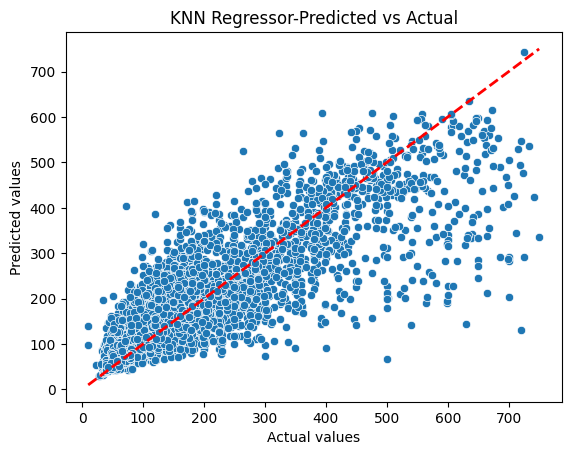

In [14]:

# Predict on test set
y_pred = knn_tuned.predict(X_test_full_np_df)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
# Print metrics
print(f"The R² of the model on the TEST set is: {r2: .2f}")
print(f"Mean Absolute Error (MAE): {mae: .2f}")
print(f"Mean Squared Error (MSE): {mse: .2f}")
print(f"Root Mean Squared Error (RMSE): {rmse: .2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape: .2f}")

#scatter plot
sns.scatterplot(x=y_test, y=y_pred)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred)),
    max(max(y_test), max(y_pred))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("KNN Regressor-Predicted vs Actual")
plt.show()

# Decision Tree Regressor Before Tuning

MAE,  66.37
MSE,  9268.79
RMSE,  96.27
R2 score,  0.54
MAPE,  45.04


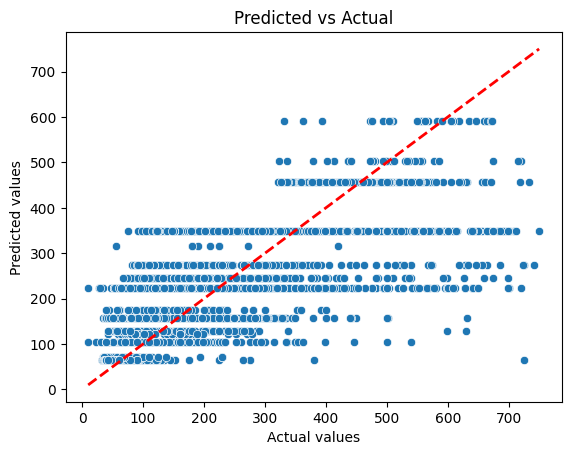

In [34]:
#initialize decision tree instance
dtree = DecisionTreeRegressor(max_depth=4)
#train a Decision Tree
dtree.fit(X_train_full_np_df, y_train)
y_pred_test_dt = dtree.predict(X_test_full_np_df)
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_dt): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"R2 score, {dtree.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_dt) * 100: .2f}")


#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_dt)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_dt)),
    max(max(y_test), max(y_pred_test_dt))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual")
plt.show()

# Hyperparameter Tuning for Decision Tree Regressor

# Grid Search

In [15]:
# Hyperparameter grid
parameter_grid={
    "max_depth": [None,5,10,20],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,5],
    "max_features":[None,0.5,'sqrt','log2'],
    "criterion":['squared_error','absolute_error']
}

# Model
dt=DecisionTreeRegressor(random_state=42)

# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(dt, param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Time taken: 299.38 seconds
Best hyperparameters: {'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Cross-validated R2 score: 0.6327
95% Confidence Interval for R2: (0.6101, 0.6327, 0.6553)

 Test Evaluation:
MAE : 56.0574
MSE : 7278.4562
RMSE: 85.3139
R2  : 0.6414
MAPE  : 34.7452


# Random Search

In [16]:
# Define parameters
parameter_distributions = {
    "max_depth": [None,5,10,20,30],
    "min_samples_split": randint(2,20),
    "min_samples_leaf":randint(1,20) ,
    "max_features":[None,0.5,'sqrt','log2'],
    "criterion":['squared_error','absolute_error'],
    "ccp_alpha":uniform(0.0,0.05)
}

# Model instance
dt1 =  DecisionTreeRegressor()

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    dt1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5; 1/50] START ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=log2, min_samples_leaf=7, min_samples_split=12
[CV 5/5; 1/50] START ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=log2, min_samples_leaf=7, min_samples_split=12[CV 4/5; 1/50] START ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=log2, min_samples_leaf=7, min_samples_split=12

[CV 2/5; 1/50] START ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=log2, min_samples_leaf=7, min_samples_split=12
[CV 3/5; 1/50] START ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=log2, min_samples_leaf=7, min_samples_split=12
[CV 1/5; 2/50] START ccp_alpha=0.022962444598293358, criterion=squared_error, max_depth=20, max_features=log2, min_samples_leaf=3, min_samples_split=3
[CV 4/5; 1/50] END ccp_alph

# Bayesian Search

In [17]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    max_depth = trial.suggest_int("max_depth", 1, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2", 0.5, 0.8, 1.0])
    criterion = trial.suggest_categorical("criterion", ["squared_error", "absolute_error"])
    ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 0.05)

    # Initialize model
    dt2 = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        ccp_alpha=ccp_alpha,
        random_state=42
    )

    # Cross-validation
    scores = cross_val_score(dt2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-12 17:07:59,137] A new study created in memory with name: no-name-dbb89279-c98b-4c09-9d06-2b13edd7151a
[I 2025-08-12 17:07:59,519] Trial 0 finished with value: 0.6126158338509079 and parameters: {'max_depth': 22, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': 1.0, 'criterion': 'squared_error', 'ccp_alpha': 0.009057435188198083}. Best is trial 0 with value: 0.6126158338509079.
[I 2025-08-12 17:07:59,625] Trial 1 finished with value: 0.5817359427304603 and parameters: {'max_depth': 36, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'squared_error', 'ccp_alpha': 0.03892371688033763}. Best is trial 0 with value: 0.6126158338509079.
[I 2025-08-12 17:07:59,827] Trial 2 finished with value: 0.6074833858123478 and parameters: {'max_depth': 47, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 0.5, 'criterion': 'squared_error', 'ccp_alpha': 0.019832395585808123}. Best is trial 0 with value: 0.6126158338509079.
[I 20



Time taken:  239.5782 seconds

Best hyperparameters found: {'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 18, 'max_features': None, 'criterion': 'squared_error', 'ccp_alpha': 0.02875715043576124}
 Best R² found:  0.6419
 R² confidence interval of best trial: (np.float64(0.6185), np.float64(0.6419), np.float64(0.6654))


# Decision Tree Regressor After Tuning

MAE,  53.31
MSE,  6775.87
RMSE,  82.32
R2 score,  0.67
MAPE,  32.81


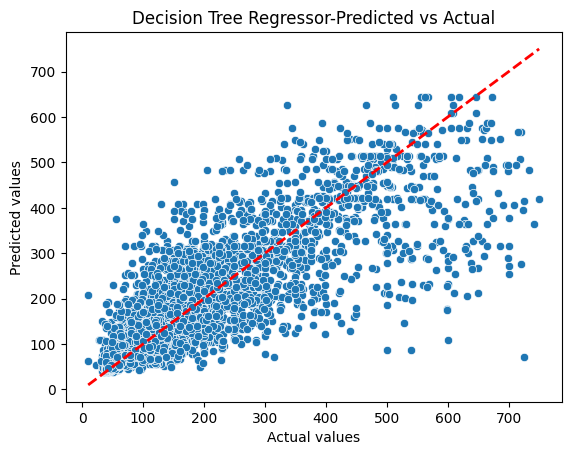

In [15]:
#initialize decision tree instance
dtree_tuned = DecisionTreeRegressor(max_depth=24 ,min_samples_split=4 ,min_samples_leaf=18,max_features=None,criterion='squared_error')
 
#train a Decision Tree
dtree_tuned.fit(X_train_full_np_df, y_train)
y_pred_test_dt = dtree_tuned.predict(X_test_full_np_df)
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_dt): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"R2 score, {dtree_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_dt) * 100: .2f}")


#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_dt)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_dt)),
    max(max(y_test), max(y_pred_test_dt))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Decision Tree Regressor-Predicted vs Actual")
plt.show()

# Saving Model

In [16]:
with open("../models/dtree_tuned.pkl", "wb") as file:
    pickle.dump(dtree_tuned, file)

# Random Forest Regressor Before Tuning

MAE,  46.19
MSE,  5166.86
RMSE,  71.88
R2 score,  0.75
MAPE,  28.69


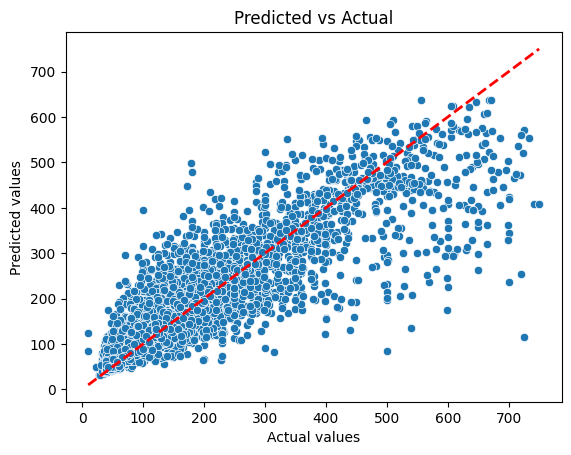

In [37]:
#initialize a random Forest
rforest = RandomForestRegressor(n_estimators=200,
                             max_depth=30)
#Training the model
rforest.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_rf = rforest.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test, y_pred_test_rf): .2f}")
print(f"MSE, {mean_squared_error(y_test, y_pred_test_rf): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test, y_pred_test_rf): .2f}")
print(f"R2 score, {rforest.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_rf) * 100: .2f}")


#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_rf)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_rf)),
    max(max(y_test), max(y_pred_test_rf))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual")
plt.show()

# Hyperparameter Tuning for Random Forest Regressor

# Grid Search

In [22]:
# Hyperparameter grid
parameter_grid={
    
    'n_estimators': [100, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['log2', 'sqrt']
}

# Model
rf=RandomForestRegressor(random_state=42)

# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(rf, param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/opt/homebrew/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Time taken: 89.64 seconds
Best hyperparameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Cross-validated R2 score: 0.7302
95% Confidence Interval for R2: (0.7137, 0.7302, 0.7468)

 Test Evaluation:
MAE : 45.2685
MSE : 4965.5397
RMSE: 70.4666
R2  : 0.7554
MAPE  : 28.4354


# Random Search

In [23]:
# Define parameters
parameter_distributions = {

    'n_estimators': randint(100, 300),
    'max_depth': randint(10, 40),
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Model instance
rf1 =  RandomForestRegressor()

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    rf1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test,y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test,y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test,y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5; 1/50] START max_depth=16, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=206
[CV 2/5; 1/50] START max_depth=16, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=206
[CV 3/5; 1/50] START max_depth=16, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=206
[CV 4/5; 1/50] START max_depth=16, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=206
[CV 5/5; 1/50] START max_depth=16, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=206
[CV 1/5; 2/50] START max_depth=17, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=221
[CV 2/5; 2/50] START max_depth=17, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=221
[CV 3/5; 2/50] START max_depth=17, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=221
[CV 4/5; 2/50] START max_depth=17, max_fea

/opt/homebrew/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 5/5; 4/50] START max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=230
[CV 1/5; 3/50] END max_depth=28, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=187;, score=0.720 total time=   4.2s
[CV 3/5; 3/50] END max_depth=28, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=187;, score=0.743 total time=   4.1s
[CV 1/5; 5/50] START max_depth=31, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=257
[CV 2/5; 3/50] END max_depth=28, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=187;, score=0.737 total time=   4.2s
[CV 2/5; 5/50] START max_depth=31, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=257
[CV 5/5; 3/50] END max_depth=28, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=187;, score=0.708 total time=   4.1s
[CV 3/5; 5/50] START max_depth=31, max_features=sqrt, min_samples_leaf=2, min_samples_split=

# Bayesian Search

In [26]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    params={'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42
    }

    # Initialize model
    rf2 = RandomForestRegressor(**params)
    

    # Cross-validation
    scores = cross_val_score(rf2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-14 09:12:27,465] A new study created in memory with name: no-name-abd11a79-b28e-4af6-84f3-85fc00d9db72
[I 2025-08-14 09:12:50,765] Trial 0 finished with value: 0.7183864336569453 and parameters: {'n_estimators': 204, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.7183864336569453.
[I 2025-08-14 09:13:17,515] Trial 1 finished with value: 0.727241412041168 and parameters: {'n_estimators': 225, 'max_depth': 27, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 0.727241412041168.
[I 2025-08-14 09:13:35,369] Trial 2 finished with value: 0.6989566593409184 and parameters: {'n_estimators': 267, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 0.727241412041168.
[I 2025-08-14 09:13:51,215] Trial 3 finished with value: 0.7078352896477765 an



Time taken:  1252.8959 seconds

Best hyperparameters found: {'n_estimators': 266, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}
 Best R² found:  0.7305
 R² confidence interval of best trial: (np.float64(0.7086), np.float64(0.7305), np.float64(0.7524))


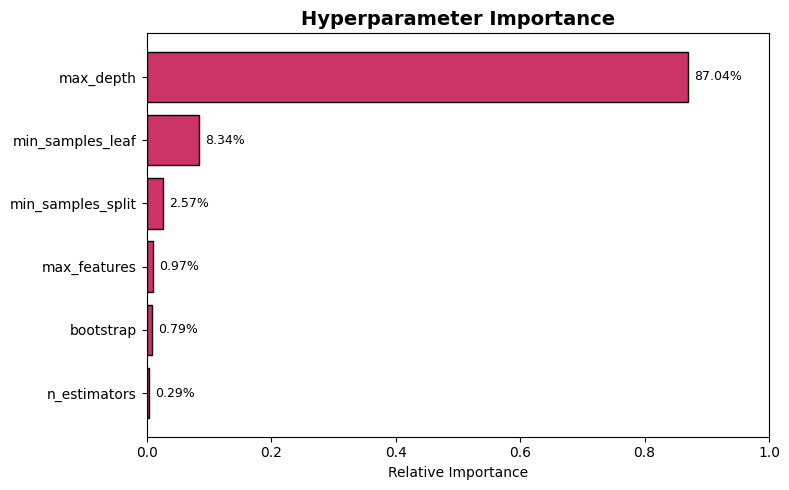

In [32]:


# Get Optuna parameter importances as a dictionary
param_importances = optuna.importance.get_param_importances(study)

# Convert to DataFrame for plotting
df_importances = pd.DataFrame(
    list(param_importances.items()), columns=['Parameter', 'Importance']
)

# Sort by importance descending
df_importances = df_importances.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(
    df_importances['Parameter'], 
    df_importances['Importance'], 
    color='#CC3366', edgecolor='black'
)

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f"{width:.2%}", va='center', fontsize=9)

plt.title('Hyperparameter Importance', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.xlim(0, 1)
plt.tight_layout()

plt.show()


# Random Forest Regressor After Tuning

MAE,  44.54
MSE,  4895.08
RMSE,  69.96
R2 score,  0.76
MAPE,  27.49


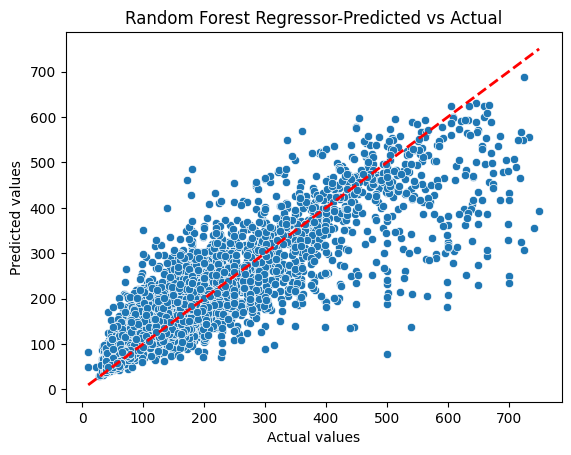

In [30]:
#initialize a random Forest
rforest_tuned = RandomForestRegressor(max_depth=26,max_features='log2',min_samples_leaf=1,min_samples_split=3,n_estimators=282,bootstrap=False,random_state=42)

#Training the model
rforest_tuned.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_rf = rforest_tuned.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test,y_pred_test_rf): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_rf): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_rf): .2f}")
print(f"R2 score, {rforest_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test,y_pred_test_rf) * 100: .2f}")


#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_rf)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_rf)),
    max(max(y_test), max(y_pred_test_rf))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Random Forest Regressor-Predicted vs Actual")
plt.show()

# Saving Model

In [18]:
with open("../models/rforest_tuned.pkl", "wb") as file:
    pickle.dump(rforest_tuned, file)

# Ada Boost Regressor Before Tuning

MAE,  43.06
MSE,  5041.89
RMSE,  71.01
R2 score,  0.75
MAPE,  25.55


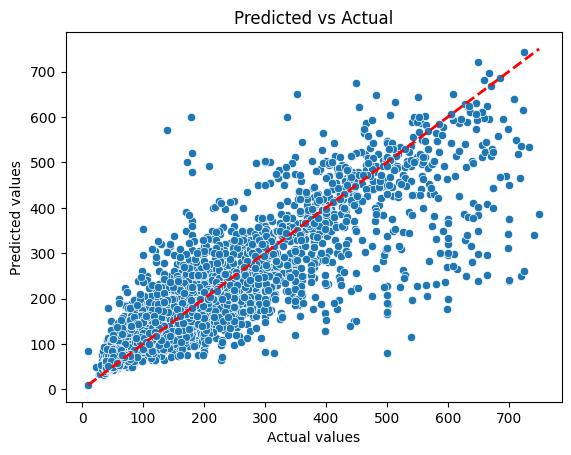

In [40]:
#Initialize an AdaBoost model
ada = AdaBoostRegressor(DecisionTreeRegressor(max_depth=20),
                            n_estimators=100)
#Training the model
ada.fit(X_train_full_np_df, y_train)
y_pred_test_ada = ada.predict(X_test_full_np_df)
#Evaluate the model
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_ada): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_ada): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_ada): .2f}")
print(f"R2 score, {ada.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test,y_pred_test_ada) * 100: .2f}")

#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_ada)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_ada)),
    max(max(y_test), max(y_pred_test_ada))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual")
plt.show()

# Hyperparameter Tuning for Ada Boost Regressor

# Grid Search

In [32]:
# Hyperparameter grid
parameter_grid={
    
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'loss': ['linear', 'square', 'exponential'],
    'estimator__max_depth': [10, 15, 20]
}

base_estimator=DecisionTreeRegressor()
ab=AdaBoostRegressor


# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(estimator=ab(random_state=42,estimator=base_estimator), param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test,y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test,y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,y_pred)):.4f}")
print(f"R2  : {r2_score(y_test,y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test,y_pred) * 100:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits


/opt/homebrew/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Time taken: 369.53 seconds
Best hyperparameters: {'estimator__max_depth': 15, 'learning_rate': 1, 'loss': 'linear', 'n_estimators': 200}
Cross-validated R2 score: 0.7302
95% Confidence Interval for R2: (0.7086, 0.7302, 0.7517)

 Test Evaluation:
MAE : 45.1348
MSE : 4956.0060
RMSE: 70.3989
R2  : 0.7558
MAPE  : 28.5275


# Random Search

In [33]:
# Define parameters
parameter_distributions = {

    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 1.0),
    'loss': ['linear', 'square', 'exponential'],
    'estimator__max_depth': randint(10, 20)
}
#base estimator
base_estimator=DecisionTreeRegressor()
#model
ab1 =  AdaBoostRegressor(estimator=base_estimator,random_state=42)

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    estimator=ab1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test,y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test,y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test,y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test,y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 2/5; 1/50] START estimator__max_depth=16, learning_rate=0.8065429868602328, loss=exponential, n_estimators=156
[CV 1/5; 1/50] START estimator__max_depth=16, learning_rate=0.8065429868602328, loss=exponential, n_estimators=156
[CV 3/5; 1/50] START estimator__max_depth=16, learning_rate=0.8065429868602328, loss=exponential, n_estimators=156
[CV 4/5; 1/50] START estimator__max_depth=16, learning_rate=0.8065429868602328, loss=exponential, n_estimators=156
[CV 5/5; 1/50] START estimator__max_depth=16, learning_rate=0.8065429868602328, loss=exponential, n_estimators=156
[CV 1/5; 2/50] START estimator__max_depth=17, learning_rate=0.6086584841970366, loss=exponential, n_estimators=171
[CV 2/5; 2/50] START estimator__max_depth=17, learning_rate=0.6086584841970366, loss=exponential, n_estimators=171
[CV 3/5; 2/50] START estimator__max_depth=17, learning_rate=0.6086584841970366, loss=exponential, n_estimators=171
[CV 5/5; 2/50] STA

/opt/homebrew/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 3/5; 9/50] END estimator__max_depth=12, learning_rate=0.39246199126716275, loss=linear, n_estimators=180;, score=0.741 total time=   9.2s
[CV 2/5; 10/50] START estimator__max_depth=14, learning_rate=0.6175448519014384, loss=linear, n_estimators=122
[CV 4/5; 9/50] END estimator__max_depth=12, learning_rate=0.39246199126716275, loss=linear, n_estimators=180;, score=0.734 total time=   9.4s
[CV 4/5; 10/50] START estimator__max_depth=14, learning_rate=0.6175448519014384, loss=linear, n_estimators=122
[CV 5/5; 9/50] END estimator__max_depth=12, learning_rate=0.39246199126716275, loss=linear, n_estimators=180;, score=0.694 total time=   9.5s
[CV 5/5; 10/50] START estimator__max_depth=14, learning_rate=0.6175448519014384, loss=linear, n_estimators=122
[CV 3/5; 10/50] START estimator__max_depth=14, learning_rate=0.6175448519014384, loss=linear, n_estimators=122
[CV 1/5; 10/50] END estimator__max_depth=14, learning_rate=0.6175448519014384, loss=linear, n_estimators=122;, score=0.711 total t

# Bayesian Search

In [34]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
    loss = trial.suggest_categorical("loss", ["linear", "square", "exponential"])
    max_depth = trial.suggest_int("max_depth", 15, 20)
    
    base_estimator=DecisionTreeRegressor(max_depth=max_depth)
    # Initialize model
    ab2 = AdaBoostRegressor(
        estimator=base_estimator,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        loss=loss,
        random_state=42
    )
    

    # Cross-validation
    scores = cross_val_score(ab2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-12 17:57:26,364] A new study created in memory with name: no-name-fb337190-0005-4a3c-8498-7355eaddda4f
[I 2025-08-12 17:57:56,050] Trial 0 finished with value: 0.72723267803801 and parameters: {'n_estimators': 107, 'learning_rate': 0.942301827727182, 'loss': 'linear', 'max_depth': 15}. Best is trial 0 with value: 0.72723267803801.
[I 2025-08-12 17:59:29,708] Trial 1 finished with value: 0.7191244469587933 and parameters: {'n_estimators': 247, 'learning_rate': 0.12463685082607136, 'loss': 'linear', 'max_depth': 20}. Best is trial 0 with value: 0.72723267803801.
[I 2025-08-12 18:01:04,040] Trial 2 finished with value: 0.7105286339813655 and parameters: {'n_estimators': 238, 'learning_rate': 0.027629442606590355, 'loss': 'square', 'max_depth': 20}. Best is trial 0 with value: 0.72723267803801.
[I 2025-08-12 18:01:45,595] Trial 3 finished with value: 0.7115993109230084 and parameters: {'n_estimators': 113, 'learning_rate': 0.024330334265394903, 'loss': 'linear', 'max_depth': 17}



Time taken:  9451.9960 seconds

Best hyperparameters found: {'n_estimators': 239, 'learning_rate': 0.9999592597917758, 'loss': 'exponential', 'max_depth': 17}
 Best R² found:  0.7314
 R² confidence interval of best trial: (np.float64(0.7036), np.float64(0.7314), np.float64(0.7591))


# Ada Boost Regressor After Tuning

MAE,  43.74
MSE,  5012.23
RMSE,  70.80
R2 score,  0.75
MAPE,  26.99


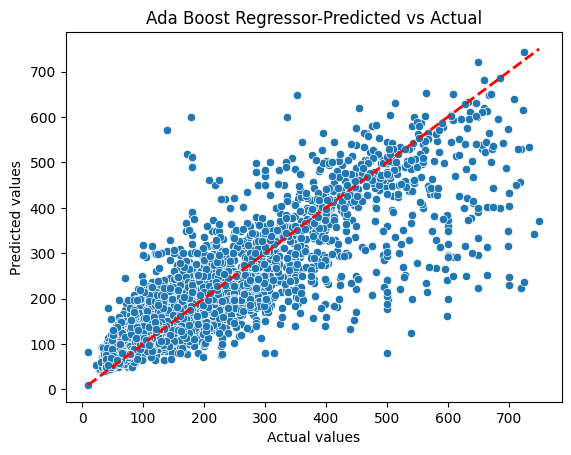

In [19]:
#Initialize an AdaBoost model
ada_tuned = AdaBoostRegressor(DecisionTreeRegressor(max_depth=18),
                            n_estimators=285,learning_rate=0.9968869366005173,loss='linear')

#Training the model
ada_tuned.fit(X_train_full_np_df, y_train)
y_pred_test_ada_tuned = ada_tuned.predict(X_test_full_np_df)
#Evaluate the model
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_ada_tuned): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_ada_tuned): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_ada_tuned): .2f}")
print(f"R2 score, {ada_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test,y_pred_test_ada_tuned) * 100: .2f}")

#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_ada_tuned)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_ada_tuned)),
    max(max(y_test), max(y_pred_test_ada_tuned))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Ada Boost Regressor-Predicted vs Actual")
plt.show()

# Saving Model

In [20]:
with open("../models/ada_tuned.pkl", "wb") as file:
    pickle.dump(ada_tuned, file)

# Gradient Boosting Regressor Before Tuning

MAE,  54.62
MSE,  8215.41
RMSE,  90.64
R2 score,  0.60
MAPE,  33.03


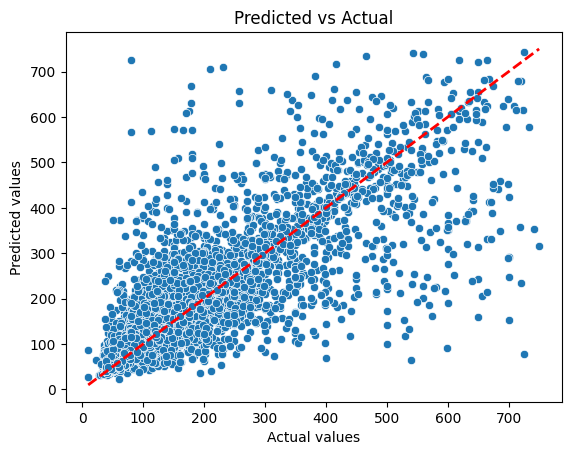

In [43]:
#Initialize GradientBoosting model
grb = GradientBoostingRegressor(max_depth=20,
                                   n_estimators=100)
grb.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_gb = grb.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test, y_pred_test_gb): .2f}")
print(f"MSE, {mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"R2 score, {grb.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_gb) * 100: .2f}")


#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_gb)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_gb)),
    max(max(y_test), max(y_pred_test_gb))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual")
plt.show()

# Hyperparameter Tuning for Gradient Boosting Regressor 

# Grid Search

In [38]:
# Hyperparameter grid
parameter_grid={
    
    'n_estimators': [100, 300],
    'learning_rate': [0.05,0.2],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'subsample': [0.6, 1.0],
    'max_features': ['sqrt', 'log2', None],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

# Model
gb=GradientBoostingRegressor(random_state=42)

# GridSearchCV setup
confidence_level = 0.95
folds = 3
gs = GridSearchCV(gb, param_grid=parameter_grid, cv=folds, verbose=2, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 3 folds for each of 576 candidates, totalling 1728 fits
[CV] END learning_rate=0.05, loss=squared_error, max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100, subsample=0.6; total time=   0.4s
[CV] END learning_rate=0.05, loss=squared_error, max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100, subsample=0.6; total time=   0.4s
[CV] END learning_rate=0.05, loss=squared_error, max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100, subsample=0.6; total time=   0.5s
[CV] END learning_rate=0.05, loss=squared_error, max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100, subsample=1.0; total time=   0.6s
[CV] END learning_rate=0.05, loss=squared_error, max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100, subsample=1.0; total time=   0.6s
[CV] END learning_rate=0.05, loss=squared_error, max_depth=3, max_

# Random search

In [39]:
# Define parameters
parameter_distributions = {

    'n_estimators': np.arange(100, 1001, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': np.arange(3, 11),
    'min_samples_split': np.arange(2, 21),
    'min_samples_leaf': np.arange(1, 11),
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2', None],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

# Model instance
gb1 =  GradientBoostingRegressor(random_state=42)

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    gb1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5; 1/50] START learning_rate=0.01, loss=squared_error, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=300, subsample=1.0
[CV 2/5; 1/50] START learning_rate=0.01, loss=squared_error, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=300, subsample=1.0
[CV 3/5; 1/50] START learning_rate=0.01, loss=squared_error, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=300, subsample=1.0
[CV 4/5; 1/50] START learning_rate=0.01, loss=squared_error, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=300, subsample=1.0
[CV 5/5; 1/50] START learning_rate=0.01, loss=squared_error, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=300, subsample=1.0
[CV 1/5; 2/50] START learning_rate=0.05, loss=absolute_error, max_depth=10, max_features=sqrt, min

# Bayesian Search

In [ ]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    params={'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'loss': trial.suggest_categorical('loss', ['squared_error', 'absolute_error', 'huber'])
    }

    # Initialize model
    gb2 = GradientBoostingRegressor(**params,random_state=42)
    

    # Cross-validation
    scores = cross_val_score(gb2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 3

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=20)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-13 13:04:45,202] A new study created in memory with name: no-name-2b7200a3-e2bd-414c-8679-29edd46c01a2
[I 2025-08-13 13:05:34,554] Trial 0 finished with value: 0.7032849472033774 and parameters: {'n_estimators': 350, 'learning_rate': 0.2271198790919194, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 9, 'subsample': 0.8178968581448993, 'max_features': None, 'loss': 'absolute_error'}. Best is trial 0 with value: 0.7032849472033774.
[I 2025-08-13 13:06:22,309] Trial 1 finished with value: 0.6869371538087758 and parameters: {'n_estimators': 350, 'learning_rate': 0.2476970820680592, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 2, 'subsample': 0.5623738013686462, 'max_features': 'log2', 'loss': 'huber'}. Best is trial 0 with value: 0.7032849472033774.
[I 2025-08-13 13:07:26,392] Trial 2 finished with value: 0.7064466627823162 and parameters: {'n_estimators': 900, 'learning_rate': 0.10734119664359751, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_

# Gradient Boosting After Tuning

MAE,  44.81
MSE,  4906.50
RMSE,  70.05
R2 score,  0.76
MAPE,  27.62


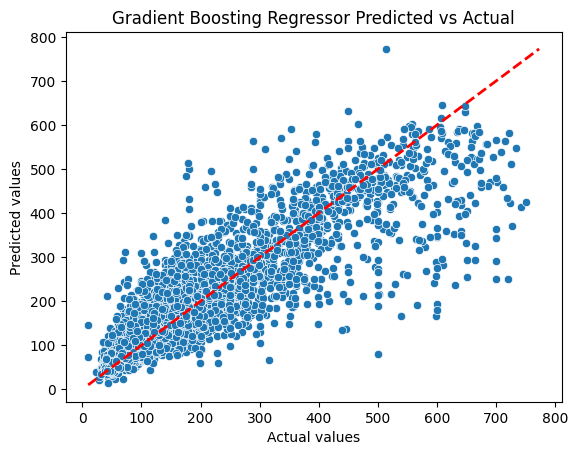

In [21]:
#Initialize GradientBoosting model
gb_tuned = GradientBoostingRegressor(subsample=0.8,max_depth=7,min_samples_split=2,min_samples_leaf=4,max_features='log2',loss='squared_error',learning_rate=0.05,
                                   n_estimators=800)

gb_tuned.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_gb = gb_tuned.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test, y_pred_test_gb): .2f}")
print(f"MSE, {mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"R2 score, {gb_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_gb) * 100: .2f}")

#scatter plot
sns.scatterplot(x=y_test, y=y_pred_test_gb)

# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_gb)),
    max(max(y_test), max(y_pred_test_gb))
]
plt.plot(lims, lims, 'r--', linewidth=2)  
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Gradient Boosting Regressor Predicted vs Actual")
plt.show()

# Saving model

In [22]:
with open("../models/gb_tuned.pkl", "wb") as file:
    pickle.dump(gb_tuned, file)

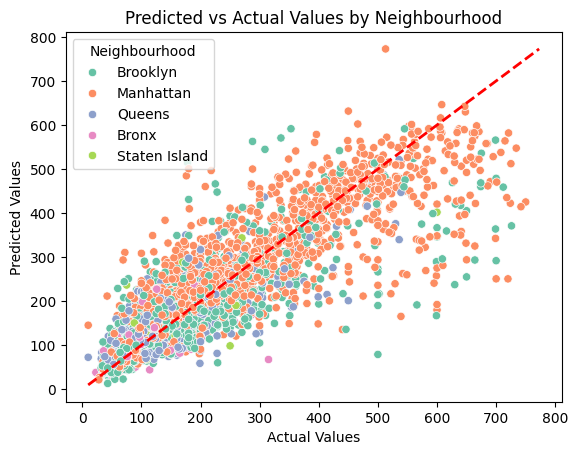

In [24]:

df_scatterplot = pd.concat([df, X_test_full_np_df], axis=1)
df_y_test_and_pred = pd.DataFrame({
    'y_test': y_test,
    'y_pred_test_gb': y_pred_test_gb
})
df_scatterplot = pd.concat([df_scatterplot, df_y_test_and_pred], axis=1)
df_scatterplot



sns.scatterplot(
    x='y_test',
    y='y_pred_test_gb',
    hue='neighbourhood_group_cleansed',  
    palette='Set2',       # choose a color palette
    data=df_scatterplot
)
# Add reference line (y = x)
lims = [
    min(min(y_test), min(y_pred_test_gb)),
    max(max(y_test), max(y_pred_test_gb))
]
plt.plot(lims, lims, 'r--', linewidth=2)  

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values by Neighbourhood')
plt.legend(title='Neighbourhood')
plt.show()

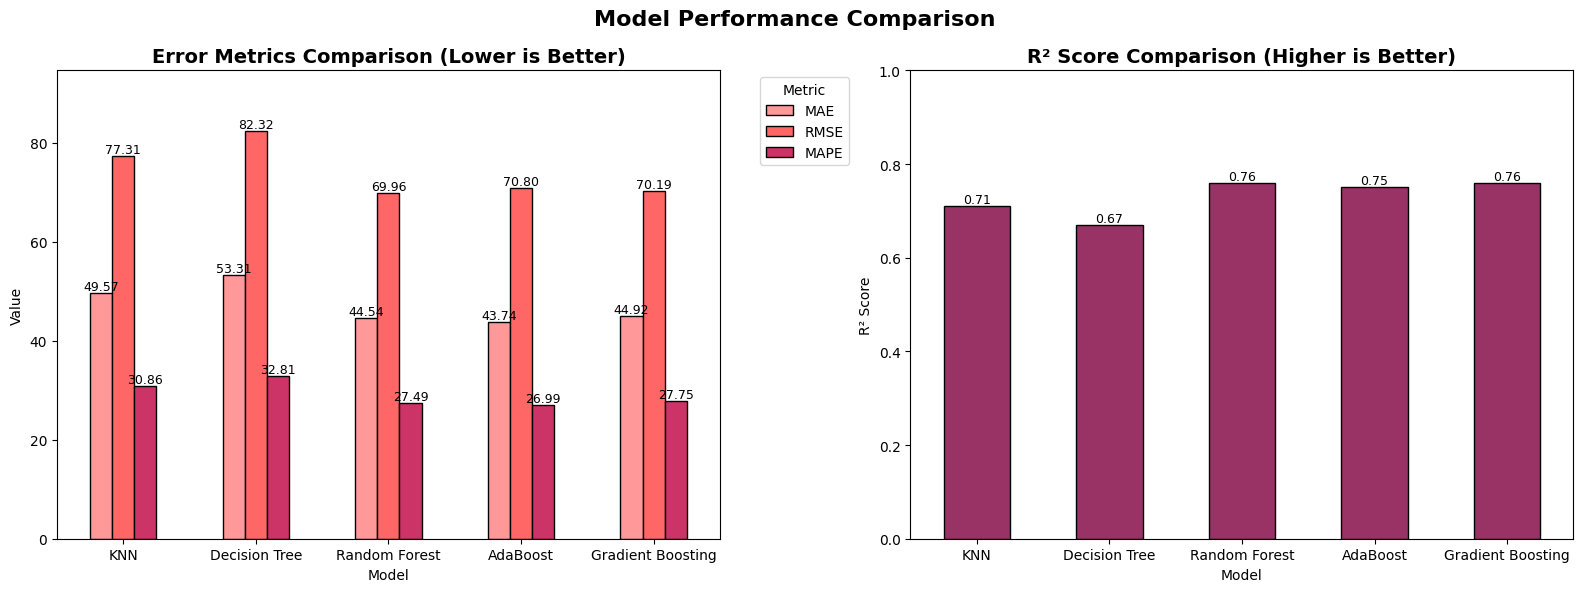

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    'Model': [
        'KNN',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'MAE': [49.57, 53.31, 44.54, 43.74, 44.92],
    'MSE': [5976.53, 6775.87, 4895.08, 5012.23, 4927.24],
    'RMSE': [77.31, 82.32, 69.96, 70.80, 70.19],
    'R2': [0.71, 0.67, 0.76, 0.75, 0.76],
    'MAPE': [30.86, 32.81, 27.49, 26.99, 27.75]
}
df = pd.DataFrame(data)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error metrics chart with legend outside
error_metrics = ['MAE', 'RMSE', 'MAPE']
df.plot(
    x='Model', y=error_metrics, kind='bar',
    ax=axes[0], color=['#FF9999', '#FF6666', '#CC3366'], edgecolor='black'
)
axes[0].set_title('Error Metrics Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0, max(df[error_metrics].max()) * 1.15)

# Make model names horizontal
axes[0].set_xticklabels(df['Model'], rotation=0)

# Add values on bars
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, rotation=0)

# Move legend outside plot
axes[0].legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# R² chart without legend
df.plot(
    x='Model', y='R2', kind='bar',
    ax=axes[1], color='#993366', edgecolor='black'
)
axes[1].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)

# Make model names horizontal
axes[1].set_xticklabels(df['Model'], rotation=0)

# Add values on bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

axes[1].legend().remove()

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


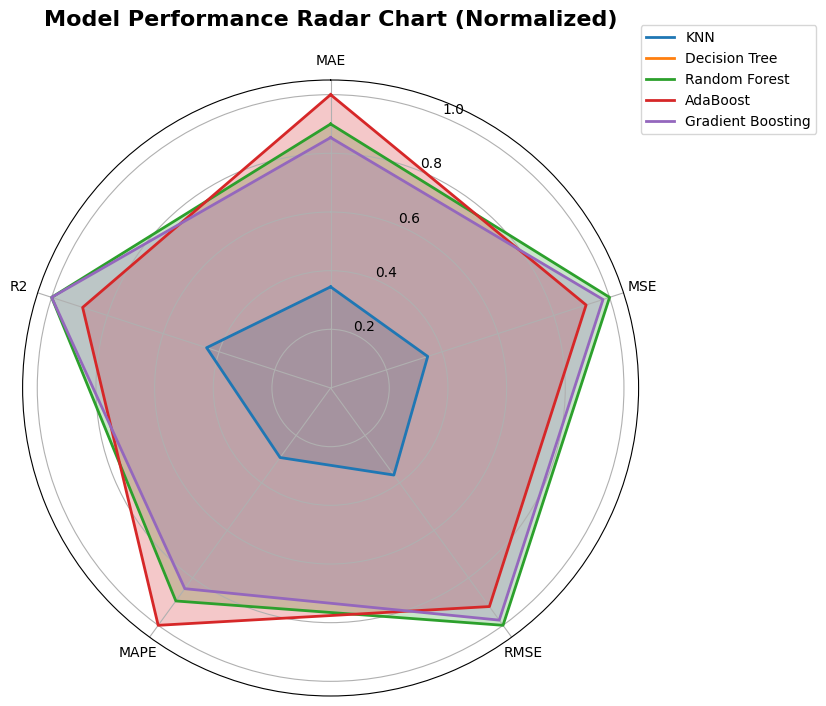

In [28]:
# ---------------------------
#  Radar Chart
# ---------------------------
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2']
df_norm = df.copy()
for m in ['MAE', 'MSE', 'RMSE', 'MAPE']:
    df_norm[m] = 1 / df[m]  # invert so higher is better
df_norm[metrics] = (df_norm[metrics] - df_norm[metrics].min()) / (df_norm[metrics].max() - df_norm[metrics].min())

labels = metrics
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, row in df_norm.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row['Model'], linewidth=2)
    ax.fill(angles, values, alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title('Model Performance Radar Chart (Normalized)', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()